In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset

In [3]:
dataset=load_dataset("CShorten/ML-ArXiv-Papers",split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
print(dataset)

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'],
    num_rows: 117592
})


In [5]:
dataset[0]

{'Unnamed: 0.1': 0,
 'Unnamed: 0': 0.0,
 'title': 'Learning from compressed observations',
 'abstract': '  The problem of statistical learning is to construct a predictor of a random\nvariable $Y$ as a function of a related random variable $X$ on the basis of an\ni.i.d. training sample from the joint distribution of $(X,Y)$. Allowable\npredictors are drawn from some specified class, and the goal is to approach\nasymptotically the performance (expected loss) of the best predictor in the\nclass. We consider the setting in which one has perfect observation of the\n$X$-part of the sample, while the $Y$-part has to be communicated at some\nfinite bit rate. The encoding of the $Y$-values is allowed to depend on the\n$X$-values. Under suitable regularity conditions on the admissible predictors,\nthe underlying family of probability distributions and the loss function, we\ngive an information-theoretic characterization of achievable predictor\nperformance in terms of conditional distortion-rat

In [6]:
import pandas as pd

In [7]:
df=pd.DataFrame(dataset)
df

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...
...,...,...,...,...
117587,4995,NaN,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...
117588,4996,NaN,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...
117589,4997,NaN,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...
117590,4998,NaN,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural..."


In [8]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'], dtype='object')

In [9]:
df=df[['title','abstract']]

In [10]:
df

,title,abstract
0,Learning from compressed observations,The problem of statistical learning is to co...
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...
...,...,...
117587,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...
117588,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...
117589,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...
117590,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural..."


In [11]:
df=df.head(15000)

In [12]:
df.shape

(15000, 2)

In [13]:
df['paper_text']=df["title"]+" "+df["abstract"]

/tmp/ipykernel_5909/1164625101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['paper_text']=df["title"]+" "+df["abstract"]


In [14]:
df[["paper_text"]].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


In [15]:
type(df[["paper_text"]].head())

pandas.core.frame.DataFrame

In [16]:
df[["paper_text"]].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


In [17]:
print(df["paper_text"].iloc[0])

Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random
variable $Y$ as a function of a related random variable $X$ on the basis of an
i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable
predictors are drawn from some specified class, and the goal is to approach
asymptotically the performance (expected loss) of the best predictor in the
class. We consider the setting in which one has perfect observation of the
$X$-part of the sample, while the $Y$-part has to be communicated at some
finite bit rate. The encoding of the $Y$-values is allowed to depend on the
$X$-values. Under suitable regularity conditions on the admissible predictors,
the underlying family of probability distributions and the loss function, we
give an information-theoretic characterization of achievable predictor
performance in terms of conditional distortion-rate functions. The ideas are
illustrated on the example of nonparametric regress

In [145]:
from sentence_transformers import SentenceTransformer


In [146]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [147]:
print(type(model))

<class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>


In [21]:
df["paper_text"] = df["paper_text"].fillna("").astype(str).str.replace("\n", " ", regex=False)

/tmp/ipykernel_5909/3926087231.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"] = df["paper_text"].fillna("").astype(str).str.replace("\n", " ", regex=False)


In [22]:
df["paper_text"]=df["paper_text"].str.strip()

/tmp/ipykernel_5909/1115159548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"]=df["paper_text"].str.strip()


In [23]:
sample_text=df["paper_text"].iloc[0]
sample_text

'Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonparametric regres

In [24]:
embedding=model.encode(sample_text)
print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [25]:
embedding[:56]

array([-0.1315641 , -0.00678266, -0.00367612,  0.03265158,  0.11219642,
        0.01227267,  0.09816719, -0.0900523 ,  0.04231161, -0.01977348,
       -0.03308417,  0.07452948,  0.10632038, -0.02060429, -0.02052106,
        0.00169493,  0.07081953,  0.05854454, -0.11231912,  0.02082474,
        0.05692544,  0.0201578 ,  0.0258311 ,  0.0321703 ,  0.10513764,
       -0.09676763,  0.02700802, -0.0234509 , -0.04549678, -0.01013699,
       -0.01794855, -0.04814427,  0.01077652, -0.03759069,  0.01943481,
        0.03715189,  0.02967844,  0.04330941,  0.04373213,  0.03704866,
       -0.00182594,  0.00455183, -0.00799067,  0.03037368, -0.014378  ,
        0.03795147,  0.0595916 , -0.02583356, -0.06521576,  0.05900268,
       -0.02107134,  0.07359422, -0.05720106,  0.00294061,  0.00767515,
       -0.0333416 ], dtype=float32)

In [26]:
sample_embedding=model.encode(df["paper_text"].head(5).to_list())

In [27]:
print(sample_embedding.shape)

(5, 384)


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

In [29]:
similarity=cosine_similarity(sample_embedding[0].reshape(1,-1),sample_embedding[0].reshape(1,-1))
print(similarity)

[[1.0000001]]


In [30]:
similarity=cosine_similarity(sample_embedding[0].reshape(1,-1),sample_embedding[1].reshape(1,-1))
print(similarity)

[[0.36625272]]


In [31]:
for i in range(1,5):
  sim=cosine_similarity(sample_embedding[0].reshape(1,-1),sample_embedding[i].reshape(1,-1))
  print(sim)


[[0.36625272]]
[[0.33522844]]
[[0.15505108]]
[[0.37421533]]


**Generate Full embedding**

In [32]:
import os
import numpy as np

if os.path.exists("paper_embeddings.npy"):
    print("Loading saved embeddings")
    embeddings = np.load("paper_embeddings.npy")
else:
    print("Generating embeddings")
    embeddings = model.encode(
        df["paper_text"].tolist(),
        batch_size=32,
        show_progress_bar=True
    )
    np.save("paper_embeddings.npy", embeddings)
    print("Embeddings saved successfully!")

Loading saved embeddings


In [33]:
print(embedding.shape)

(384,)


In [34]:
print(type(embedding))

<class 'numpy.ndarray'>


In [35]:
!pip install faiss-cpu

In [36]:
import faiss

In [37]:
if os.path.exists("paper_faiss.index"):
    print("Loading existing FAISS index")
    index = faiss.read_index("paper_faiss.index")
else:
    print("Creating new FAISS index")
    faiss.normalize_L2(embeddings)
    index = faiss.IndexFlatIP(384)
    index.add(embeddings)
    faiss.write_index(index, "paper_faiss.index")
    print("FAISS index saved successfully!")

Loading existing FAISS index


In [38]:
# faiss.normalize_L2(embedding)

In [39]:
# index=faiss.IndexFlatIP(384)

In [40]:
# index.add(embedding)

In [41]:
print(index.ntotal)

15000


In [42]:
query="deep learning for medical image analysis"
query_embedding=model.encode([query])
query_embedding.shape


(1, 384)

In [43]:
faiss.normalize_L2(query_embedding)

In [44]:
D,I=index.search(query_embedding,5)
# index.search(query_embedding,k)  k is basically top k similar embedding
# D=>score(similarity score) ,  I=>indeces
print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [45]:
print(df.iloc[10466]["title"])

A Perspective on Deep Imaging


In [46]:
print(df.iloc[11873]["title"])

Classification of MRI data using Deep Learning and Gaussian
  Process-based Model Selection


In [47]:
def search_paper(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  return D,I

In [48]:
D,I=search_paper("deep learning for medical image analysis")
print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [49]:
def search_paper(query,k):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  for score ,idx in zip(D[0],I[0]):
    print("Similarity score",score)
    print("Title : ",df.iloc[idx]["title"])
    print("Abstract : ",df.iloc[idx]["abstract"][:500])
    print("\n")



In [50]:
search_paper("deep learning for medical image analysis",5)

Similarity score 0.6807244
Title :  A Perspective on Deep Imaging
Abstract :    The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance


Similarity score 0.67092204
Title :  Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Abstract :    Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, fo

In [51]:
!pip install transformers==4.46.3

In [52]:
from transformers import pipeline

In [53]:
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [54]:
summary = summarizer(
    df.iloc[10466]["abstract"],
    max_length=120,
    min_length=40
)
print(summary)

[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]


In [55]:
summary[0]['summary_text']

'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'

In [56]:
def search_paper(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  for score ,idx in zip(D[0],I[0]):
    print("Similarity score",score)
    print("Title : ",df.iloc[idx]["title"])
    print("Abstract : ",df.iloc[idx]["abstract"][:500])
    summary = summarizer(
    df.iloc[idx]["abstract"],
    max_length=120,
    min_length=40
    )
    print("Summary : ",summary[0]['summary_text'])

    print("\n")

In [57]:
search_paper("deep learning for medical image analysis")

Similarity score 0.6807244
Title :  A Perspective on Deep Imaging
Abstract :    The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance
Summary :  The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.


Similarity score 0.67092204
Title :  Convolutional Neural Networks 

In [58]:
!pip install keybert==0.8.5

In [59]:
from keybert import KeyBERT
kw_model=KeyBERT()

In [60]:
type(kw_model)#mode=SentenceTransformer("all-MiniLM-L6-v2")

keybert._model.KeyBERT

In [61]:
text=df.iloc[10466]["abstract"]
keywords=kw_model.extract_keywords(text)

In [62]:
print(keywords)

[('imaging', 0.4528), ('tomographic', 0.4488), ('reconstruction', 0.3623), ('deep', 0.3003), ('learning', 0.2622)]


In [63]:
KEYWORDS=kw_model.extract_keywords(text,keyphrase_ngram_range=(1,3),stop_words="english")


In [64]:
print(KEYWORDS)

[('tomographic imaging deep', 0.6704), ('imaging deep learning', 0.6543), ('learning medical imaging', 0.6041), ('imaging deep', 0.5919), ('medical imaging', 0.5281)]


In [65]:
def search_paper(query,k):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  for score ,idx in zip(D[0],I[0]):
    print("Similarity score",score)
    print("Title : ",df.iloc[idx]["title"])
    print("Abstract : ",df.iloc[idx]["abstract"][:500])
    summary = summarizer(
    df.iloc[idx]["abstract"],
    max_length=120,
    min_length=40
    )
    print("Summary : ",summary[0]['summary_text'])
    KEYWORDS=kw_model.extract_keywords(df.iloc[idx]["abstract"],keyphrase_ngram_range=(1,3),stop_words="english")
    print("Keywords : ",KEYWORDS)
    # for keyword in KEYWORDS:
    #   print(keyword[0])

    print("\n")

In [66]:
search_paper("deep learning for medical image analysis",2)

Similarity score 0.6807244
Title :  A Perspective on Deep Imaging
Abstract :    The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance
Summary :  The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.
Keywords :  [('tomographic imaging deep', 0.6704), ('imaging deep lea

In [126]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
import json
import re
genai.configure(api_key="YOUR_GEMINI_API_KEY")
LLM = genai.GenerativeModel("gemini-2.5-flash")

In [139]:
def extract_entities_llm(text):

    prompt = f"""
You are an AI Research Paper Analyzer.

Extract the following entities from the research paper.

Return ONLY valid JSON.

Required format:

{{
  "Models": [],
  "Datasets": [],
  "Methods": [],
  "Frameworks": [],
  "Metrics": [],
  "Optimizers": []
}}

Research Paper:

{text}
"""

    try:

        response = LLM.generate_content(prompt)

        result = response.text.strip()

        # Remove markdown if Gemini returns ```json
        result = re.sub(r"```json", "", result)
        result = re.sub(r"```", "", result)

        entities = json.loads(result)

        return entities

    except Exception as e:

        print("Entity Extraction Error:", e)

        return {
            "Models": [],
            "Datasets": [],
            "Methods": [],
            "Frameworks": [],
            "Metrics": [],
            "Optimizers": []
        }

In [165]:
def search_paper(query, k):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)

    for score, idx in zip(D[0], I[0]):
        print("-" * 100)
        print(f"Similarity Score : {score:.4f}")
        print("\nTitle :")
        print(df.iloc[idx]["title"])
        print("\nAbstract :")
        print(df.iloc[idx]["abstract"][:500])

        # SUMMARY
        summary = summarizer(
            df.iloc[idx]["abstract"],
            max_length=120,
            min_length=40,
            do_sample=False
        )

        print("\nSummary :")
        print(summary[0]["summary_text"])

        #KEYWORDS
        keywords = kw_model.extract_keywords(
            df.iloc[idx]["abstract"],
            keyphrase_ngram_range=(1,3),
            stop_words="english"
        )
        print("\nKeywords :")

        for keyword, score_kw in keywords:
            print(f" • {keyword} ({score_kw:.4f})")

        # LLM ENTITY EXTRACTION
        entities = extract_entities_llm(df.iloc[idx]["abstract"])
        print("\nResearch Entities")
        for category, values in entities.items():
            if not values:
                continue
            print(f"\n{category}")
            for value in values:
                print(f" • {value}")
        print("\n")

In [166]:
search_paper("deep learning for medical image analysis",2)

----------------------------------------------------------------------------------------------------
Similarity Score : 0.6807

Title :
A Perspective on Deep Imaging

Abstract :
  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

Summary :
The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior perform

In [167]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [173]:
def similarity_heatmap(indices):
    texts = df.iloc[indices]["paper_text"].tolist()
    embeddings = model.encode(texts)
    sim = cosine_similarity(embeddings)
    labels = [
        f"P{i+1}"
        for i in range(len(indices))
    ]

    plt.figure(figsize=(6,5))

    ax = plt.gca()

    heatmap = ax.imshow(
        sim,
        cmap="Blues",
        vmin=0.5,
        vmax=1,
        interpolation="nearest"
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(labels, fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)

    ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)

    ax.grid(which="minor",
            color="white",
            linestyle="-",
            linewidth=2)

    ax.tick_params(which="minor",
                   bottom=False,
                   left=False)

    for i in range(len(labels)):
        for j in range(len(labels)):

            value = sim[i, j]

            color = "white" if value > 0.80 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=color
            )

    plt.title(
        "Paper Similarity Matrix",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    cbar = plt.colorbar(heatmap, shrink=0.8)
    cbar.outline.set_visible(False)
    cbar.set_label("Similarity", fontsize=11)

    plt.tight_layout()

    plt.show()
    print("\nPaper Index")
    print("-"*35)

    for i, idx in enumerate(indices):
        print(f"P{i+1} : {df.iloc[idx]['title']}")

In [174]:
def search_paper(query, k):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)
    retrieved_indices=[]
    for score, idx in zip(D[0], I[0]):
        retrieved_indices.append(idx)
        print("-" * 100)
        print(f"Similarity Score : {score:.4f}")
        print("\nTitle :")
        print(df.iloc[idx]["title"])
        print("\nAbstract :")
        print(df.iloc[idx]["abstract"][:500])

        # SUMMARY
        summary = summarizer(
            df.iloc[idx]["abstract"],
            max_length=120,
            min_length=40,
            do_sample=False
        )

        print("\nSummary :")
        print(summary[0]["summary_text"])

        #KEYWORDS
        keywords = kw_model.extract_keywords(
            df.iloc[idx]["abstract"],
            keyphrase_ngram_range=(1,3),
            stop_words="english"
        )
        print("\nKeywords :")

        for keyword, score_kw in keywords:
            print(f" • {keyword} ({score_kw:.4f})")

        # LLM ENTITY EXTRACTION
        entities = extract_entities_llm(df.iloc[idx]["abstract"])
        print("\nResearch Entities")
        for category, values in entities.items():
            if not values:
                continue
            print(f"\n{category}")
            for value in values:
                print(f" • {value}")
        print("\n")
     # Heatmap

    print("=" * 100)
    print("Generating Similarity Heatmap...\n")

    similarity_heatmap(retrieved_indices)

----------------------------------------------------------------------------------------------------
Similarity Score : 0.6807

Title :
A Perspective on Deep Imaging

Abstract :
  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

Summary :
The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior perform

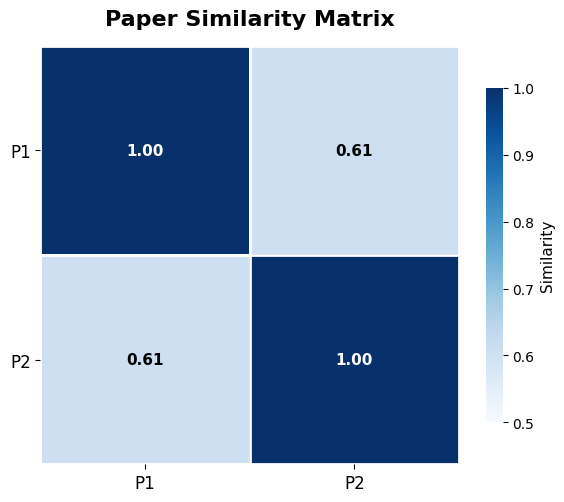


Paper Index
-----------------------------------
P1 : A Perspective on Deep Imaging
P2 : Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?


In [175]:
search_paper("deep learning for medical image analysis",2)